In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data.csv")
df.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,gender_female,gender_male,radiation_therapy_no,radiation_therapy_yes,Tumor_purity,years_to_birth,survival_3yr
0,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.9027,-0.925152,1
1,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.7466,1.815359,0
2,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.7702,0.064477,1
3,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.9178,-0.468400,1
4,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.8886,0.521229,1


In [3]:
from imblearn.over_sampling import RandomOverSampler
X = df.drop('survival_3yr', axis=1)
y = df['survival_3yr']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [4]:
def find_threshold_for_min_recall(y_true, y_proba, min_recall=0.70):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    precision = np.append(precision, 1.0)
    recall = np.append(recall, 0.0)
    thresholds = np.append(thresholds, 1.0)
    valid = recall >= min_recall
    if not np.any(valid):
        return None, None, None, None
    best_idx = np.argmax(precision * valid)
    p, r, t = precision[best_idx], recall[best_idx], thresholds[best_idx]
    f1 = f1_score_from_pr(p, r)
    return t, p, r, f1

def f1_score_from_pr(p, r):
    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)


In [5]:
pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model_configs = {
    "Regresión Logística": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
        "params": {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__solver": ['liblinear', 'saga']}
    },
    "SVM": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", SVC(class_weight='balanced', probability=True, random_state=42))]),
        "params": {"clf__C": [0.1, 1, 10], "clf__gamma": ['scale', 'auto', 0.001, 0.01], "clf__kernel": ['rbf', 'linear']}
    },
    "KNN": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "params": {"clf__n_neighbors": [3, 5, 7, 9, 11], "clf__weights": ['uniform', 'distance'], "clf__metric": ['euclidean', 'manhattan']}
    },
    "Random Forest": {
        "pipeline": Pipeline([("clf", RandomForestClassifier(class_weight='balanced', random_state=42))]),
        "params": {"clf__n_estimators": [50, 100, 200], "clf__max_depth": [3, 5, 7, None], "clf__min_samples_split": [2, 5, 10]}
    },
    "Gradient Boosting": {
        "pipeline": Pipeline([("clf", GradientBoostingClassifier(random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__learning_rate": [0.01, 0.1, 0.2],
            "clf__max_depth": [3, 5, 7],
            "clf__subsample": [0.8, 1.0]
        }
    },
    "AdaBoost": {
        "pipeline": Pipeline([("clf", AdaBoostClassifier(random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0]
        }
    },
    "Extra Trees": {
        "pipeline": Pipeline([("clf", ExtraTreesClassifier(class_weight='balanced', random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 5, 7, None],
            "clf__min_samples_split": [2, 5, 10]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([("clf", XGBClassifier(
            scale_pos_weight=pos_weight,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.01, 0.1, 0.2],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0]
        }
    }
}

In [6]:
results = []
min_recall_required = 0.70
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"🔍 Optimizando {len(model_configs)} modelos con búsqueda aleatoria (20 iteraciones c/u)...")
print(f"🎯 Requiere recall ≥ {min_recall_required:.0%} en clase positiva ('Fallece <3 años')\n")

for name, config in model_configs.items():
    print(f"🔹 {name}")
    
    search = RandomizedSearchCV(
        config["pipeline"],
        config["params"],
        n_iter=20,
        cv=cv,
        scoring='average_precision',  # mejor que AUC-ROC en clases desbalanceadas
        n_jobs=-1,
        random_state=42
    )
    
    try:
        search.fit(X_train, y_train)
    except Exception as e:
        print(f"   ❌ Error durante entrenamiento: {e}\n")
        continue
    
    best_model = search.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    thresh, prec, rec, f1 = find_threshold_for_min_recall(y_test, y_proba, min_recall=min_recall_required)
    
    if thresh is None:
        print(f"   ❌ No alcanza recall ≥ {min_recall_required:.0%}\n")
        continue
    
    y_pred = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    vpn = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    
    results.append({
        "Modelo": name,
        "Umbral": thresh,
        "Recall": rec,
        "Precisión": prec,
        "F1-score": f1,
        "VPN": vpn,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "best_params": search.best_params_
    })
    
    print(f"   ✅ Recall: {rec:.1%} | Precisión: {prec:.1%} | F1: {f1:.3f} | Umbral: {thresh:.3f}")
    print(f"   📊 AUC-PR: {auc_pr:.3f} | VPN: {vpn:.1%}\n")


🔍 Optimizando 8 modelos con búsqueda aleatoria (20 iteraciones c/u)...
🎯 Requiere recall ≥ 70% en clase positiva ('Fallece <3 años')

🔹 Regresión Logística
   ✅ Recall: 87.1% | Precisión: 40.3% | F1: 0.551 | Umbral: 0.413
   📊 AUC-PR: 0.448 | VPN: 84.6%

🔹 SVM
   ✅ Recall: 80.6% | Precisión: 40.3% | F1: 0.538 | Umbral: 0.216
   📊 AUC-PR: 0.409 | VPN: 80.6%

🔹 KNN
   ✅ Recall: 83.9% | Precisión: 37.7% | F1: 0.520 | Umbral: 0.359
   📊 AUC-PR: 0.361 | VPN: 79.2%

🔹 Random Forest
   ✅ Recall: 71.0% | Precisión: 41.5% | F1: 0.524 | Umbral: 0.340
   📊 AUC-PR: 0.410 | VPN: 77.5%

🔹 Gradient Boosting
   ✅ Recall: 87.1% | Precisión: 43.5% | F1: 0.581 | Umbral: 0.000
   📊 AUC-PR: 0.450 | VPN: 87.1%

🔹 AdaBoost
   ✅ Recall: 87.1% | Precisión: 40.3% | F1: 0.551 | Umbral: 0.478
   📊 AUC-PR: 0.439 | VPN: 84.6%

🔹 Extra Trees
   ✅ Recall: 80.6% | Precisión: 41.7% | F1: 0.549 | Umbral: 0.301
   📊 AUC-PR: 0.376 | VPN: 81.8%

🔹 XGBoost
   ✅ Recall: 77.4% | Precisión: 42.9% | F1: 0.552 | Umbral: 0.133
  


🏆 === RESUMEN FINAL (ordenado por F1-score) ===
             Modelo  Umbral  Recall  Precisión  F1-score   VPN  AUC-ROC  AUC-PR
  Gradient Boosting   0.000   0.871      0.435     0.581 0.871    0.654   0.450
            XGBoost   0.133   0.774      0.429     0.552 0.811    0.605   0.455
Regresión Logística   0.413   0.871      0.403     0.551 0.846    0.628   0.448
           AdaBoost   0.478   0.871      0.403     0.551 0.846    0.612   0.439
        Extra Trees   0.301   0.806      0.417     0.549 0.818    0.579   0.376
                SVM   0.216   0.806      0.403     0.538 0.806    0.587   0.409
      Random Forest   0.340   0.710      0.415     0.524 0.775    0.620   0.410
                KNN   0.359   0.839      0.377     0.520 0.792    0.516   0.361


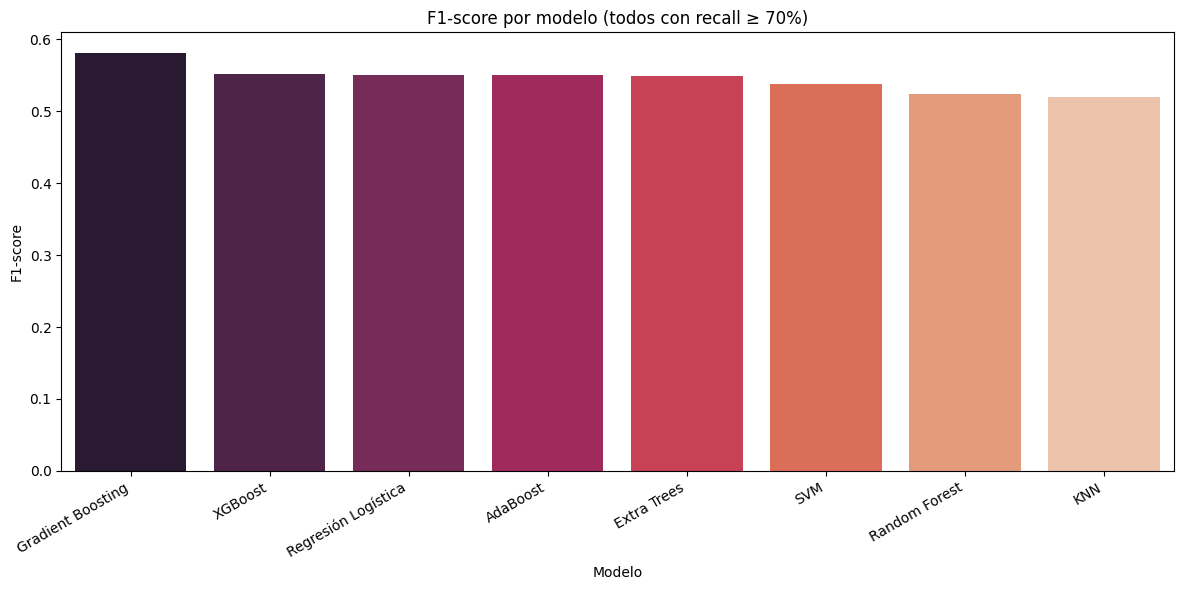

In [7]:
if results:
    summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'y_proba', 'best_params']} for r in results])
    summary_sorted = summary.sort_values('F1-score', ascending=False)
    
    print("\n🏆 === RESUMEN FINAL (ordenado por F1-score) ===")
    print(summary_sorted.to_string(index=False, float_format='%.3f'))
    
    # Guardar
    summary_sorted.to_csv("resultados_comparacion_modelos_recall70.csv", index=False)
    
    # Gráfico
    plt.figure(figsize=(12, 6))
    sns.barplot(data=summary_sorted, x='Modelo', y='F1-score', palette='rocket')
    plt.title('F1-score por modelo (todos con recall ≥ 70%)')
    plt.ylabel('F1-score')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig("f1_score_modelos.png", dpi=200)
    plt.show()
    
    # Opcional: guardar hiperparámetros
    params_summary = pd.DataFrame([{"Modelo": r["Modelo"], "Mejores Hiperparámetros": r["best_params"]} for r in results])
    params_summary.to_json("mejores_hiperparametros.json", indent=2)
    
else:
    print("❌ Ningún modelo cumplió con el recall mínimo requerido.")

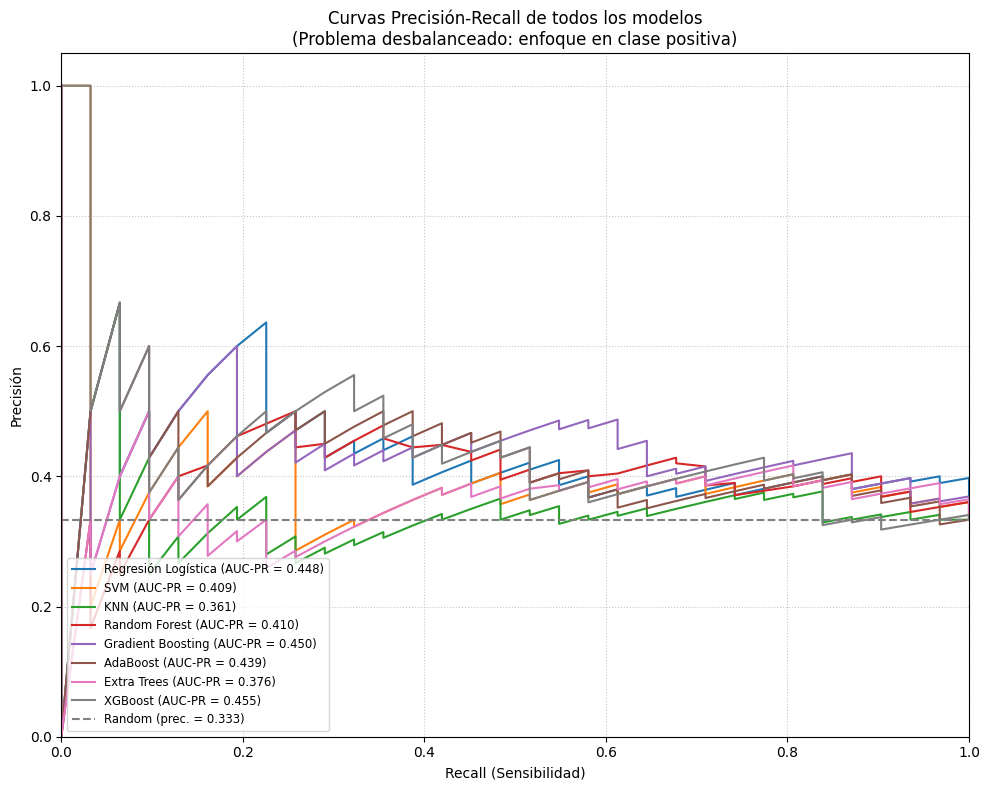

In [8]:
plt.figure(figsize=(10, 8))

for r in results:
    name = r["Modelo"]
    y_proba = r["y_proba"]
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    
    plt.plot(recall, precision, label=f'{name} (AUC-PR = {auc_pr:.3f})')

# Línea horizontal: precisión de una predicción aleatoria (baseline)
baseline_precision = np.mean(y_test)  # proporción de positivos en el conjunto de prueba
plt.axhline(y=baseline_precision, color='gray', linestyle='--', label=f'Random (prec. = {baseline_precision:.3f})')

plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precisión')
plt.title('Curvas Precisión-Recall de todos los modelos\n(Problema desbalanceado: enfoque en clase positiva)')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig("curvas_precision_recall_todos_modelos.png", dpi=200)
plt.show()

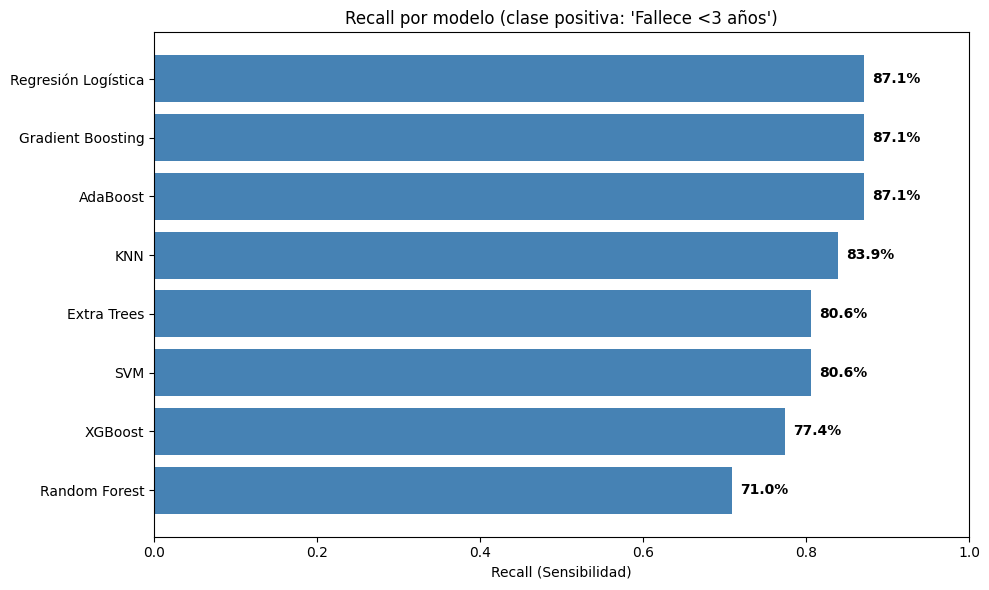

In [9]:
model_names = [r["Modelo"] for r in results]
recall_scores = [r["Recall"] for r in results]

# Crear DataFrame y ordenar por recall (descendente)
recall_df = pd.DataFrame({"Modelo": model_names, "Recall": recall_scores})
recall_df = recall_df.sort_values("Recall", ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
bars = plt.barh(recall_df["Modelo"], recall_df["Recall"], color="steelblue")
plt.xlabel("Recall (Sensibilidad)")
plt.title("Recall por modelo (clase positiva: 'Fallece <3 años')")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # Mejor legibilidad: mejor modelo arriba

# Añadir valores en las barras
for i, v in enumerate(recall_df["Recall"]):
    plt.text(v + 0.01, i, f"{v:.1%}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("recall_por_modelo.png", dpi=200)
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    recall_score, precision_score, f1_score
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# FUNCIONES AUXILIARES
# ---------------------------------------------------------

def find_threshold_for_min_recall(y_true, y_proba, min_recall=0.70):
    """
    Encuentra el umbral que logra al menos min_recall.
    Retorna (threshold, precision, recall, f1) o (None, ...) si no se logra.
    """
    thresholds = np.linspace(0, 1, 1000)
    best = None
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred)
        if rec >= min_recall:
            prec = precision_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            best = (t, prec, rec, f1)
    return best if best else (None, None, None, None)

results = []
min_recall_required = 0.70
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"🔍 Optimizando {len(model_configs)} modelos con búsqueda aleatoria (20 iteraciones c/u)...")
print(f"🎯 Requiere recall ≥ {min_recall_required:.0%} en clase positiva ('Fallece <3 años')\n")

# ---------------------------------------------------------
# BUCLE DE ENTRENAMIENTO Y EVALUACIÓN
# ---------------------------------------------------------

for name, config in model_configs.items():
    print(f"🔹 {name}")
    
    search = RandomizedSearchCV(
        config["pipeline"],
        config["params"],
        n_iter=20,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
        random_state=42,
        error_score='raise'  # para ver errores reales
    )
    
    try:
        search.fit(X_train, y_train)
    except Exception as e:
        print(f"   ❌ Error durante entrenamiento: {e}\n")
        continue
    
    best_model = search.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    thresh, prec, rec, f1 = find_threshold_for_min_recall(y_test, y_proba, min_recall=min_recall_required)
    
    if thresh is None:
        print(f"   ❌ No alcanza recall ≥ {min_recall_required:.0%}\n")
        continue
    
    y_pred = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    vpn = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    
    # ---------------------------------------------------------
    # 🔍 IMPORTANCIA POR PERMUTACIÓN (rápida y universal)
    # ---------------------------------------------------------
    try:
        perm_imp = permutation_importance(
            best_model,
            X_test,
            y_test,
            scoring='recall',      # métrica clínicamente relevante
            n_repeats=5,
            random_state=42,
            n_jobs=-1
        )
        feature_names = X_test.columns if hasattr(X_test, 'columns') else [f"Feature_{i}" for i in range(len(perm_imp.importances_mean))]
        perm_df = pd.DataFrame({
            'feature': feature_names,
            'perm_importance': perm_imp.importances_mean,
            'perm_std': perm_imp.importances_std
        }).sort_values('perm_importance', ascending=False)
        top3 = ', '.join(perm_df['feature'].head(3).tolist())
        print(f"   🧠 Top 3: {top3}")
    except Exception as e:
        print(f"   ⚠️  Error en permutación: {e}")
        perm_df = pd.DataFrame()
    
    # ---------------------------------------------------------
    # GUARDAR RESULTADOS
    # ---------------------------------------------------------
    results.append({
        "Modelo": name,
        "Umbral": thresh,
        "Recall": rec,
        "Precisión": prec,
        "F1-score": f1,
        "VPN": vpn,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "best_params": search.best_params_,
        "perm_importance": perm_df
    })
    
    print(f"   ✅ Recall: {rec:.1%} | Precisión: {prec:.1%} | F1: {f1:.3f} | Umbral: {thresh:.3f}")
    print(f"   📊 AUC-PR: {auc_pr:.3f} | VPN: {vpn:.1%}\n")

# ---------------------------------------------------------
# RESUMEN FINAL (opcional)
# ---------------------------------------------------------

if results:
    # Convertir a DataFrame para fácil visualización
    summary = pd.DataFrame([{
        "Modelo": r["Modelo"],
        "Recall": r["Recall"],
        "Precisión": r["Precisión"],
        "F1-score": r["F1-score"],
        "VPN": r["VPN"],
        "AUC-PR": r["AUC-PR"]
    } for r in results])
    
    print("\n📋 RESUMEN DE MODELOS VÁLIDOS:")
    print(summary.to_string(index=False, float_format="%.3f"))
    
    # Identificar mejor modelo por F1
    best = max(results, key=lambda x: x["F1-score"])
    print(f"\n🏆 Mejor modelo: {best['Modelo']} (F1 = {best['F1-score']:.3f})")
    
    # Mostrar top 10 variables del mejor modelo
    if not best["perm_importance"].empty:
        print("\n🧠 Top 10 variables (importancia por permutación en recall):")
        top10 = best["perm_importance"].head(10)
        for i, row in top10.iterrows():
            print(f"  {row['feature']}: {row['perm_importance']:.4f}")
    
    # Guardar métricas en CSV
    summary.to_csv("../results/model_comparison.csv", index=False)
    print("\n💾 Resultados guardados en '../results/model_comparison.csv'")
else:
    print("❌ Ningún modelo alcanzó el recall mínimo requerido.")

🔍 Optimizando 8 modelos con búsqueda aleatoria (20 iteraciones c/u)...
🎯 Requiere recall ≥ 70% en clase positiva ('Fallece <3 años')

🔹 Regresión Logística
   🧠 Top 3: years_to_birth, CD2_expression, FCGR3A_expression
   ✅ Recall: 71.0% | Precisión: 37.9% | F1: 0.494 | Umbral: 0.456
   📊 AUC-PR: 0.448 | VPN: 74.3%

🔹 SVM
   🧠 Top 3: B2M_expression, PTPRC_scna, FCER1G_expression
   ✅ Recall: 71.0% | Precisión: 40.0% | F1: 0.512 | Umbral: 0.246
   📊 AUC-PR: 0.409 | VPN: 76.3%

🔹 KNN
   🧠 Top 3: CD4_expression, years_to_birth, PTPRC_expression
   ✅ Recall: 74.2% | Precisión: 37.1% | F1: 0.495 | Umbral: 0.437
   📊 AUC-PR: 0.361 | VPN: 74.2%

🔹 Random Forest
   🧠 Top 3: SERPING1_expression, CD2_expression, C1QC_expression
   ✅ Recall: 71.0% | Precisión: 41.5% | F1: 0.524 | Umbral: 0.339
   📊 AUC-PR: 0.410 | VPN: 77.5%

🔹 Gradient Boosting
   🧠 Top 3: CD4_scna, LCP2_expression, PTPRC_scna
   ✅ Recall: 100.0% | Precisión: 33.3% | F1: 0.500 | Umbral: 0.000
   📊 AUC-PR: 0.450 | VPN: 0.0%

🔹 Ada

OSError: Cannot save file into a non-existent directory: '..\results'

In [ ]:
# ---------------------------------------------------------
# 📊 VISUALIZACIÓN DE RESULTADOS
# ---------------------------------------------------------

if not results:
    print("No hay resultados válidos para graficar.")
else:
    # 1. DataFrame de resumen
    summary_df = pd.DataFrame([{
        "Modelo": r["Modelo"],
        "Recall": r["Recall"],
        "Precisión": r["Precisión"],
        "F1-score": r["F1-score"],
        "AUC-PR": r["AUC-PR"],
        "VPN": r["VPN"]
    } for r in results])

    # Ordenar por F1
    summary_df = summary_df.sort_values("F1-score", ascending=False)

    # 2. Gráfico comparativo de métricas
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    metrics = ["Recall", "F1-score", "AUC-PR"]
    colors = ["#4CAF50", "#2196F3", "#FF9800"]

    for ax, metric, color in zip(axes, metrics, colors):
        bars = ax.bar(summary_df["Modelo"], summary_df[metric], color=color, edgecolor='black')
        ax.set_title(f"{metric}", fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=45)
        # Añadir valores en las barras
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig("../results/model_comparison_metrics.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Identificar el mejor modelo
    best_model = max(results, key=lambda x: x["F1-score"])
    best_name = best_model["Modelo"]
    print(f"\n📈 Generando gráficos para el mejor modelo: {best_name}")

    # 4. Gráfico de importancia por permutación (top 15)
    if not best_model["perm_importance"].empty:
        top_n = min(15, len(best_model["perm_importance"]))
        top_features = best_model["perm_importance"].head(top_n)

        plt.figure(figsize=(8, 6))
        bars = plt.barh(
            range(len(top_features)), 
            top_features["perm_importance"],
            xerr=top_features["perm_std"],
            color="#6A5ACD", 
            edgecolor='black',
            capsize=3
        )
        plt.yticks(range(len(top_features)), top_features["feature"])
        plt.gca().invert_yaxis()
        plt.xlabel("Reducción en Recall (Importancia por Permutación)")
        plt.title(f"Importancia de variables – {best_name}", fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"../results/feature_importance_{best_name.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("   ⚠️  No hay datos de importancia para el mejor modelo.")

    # 5. Curvas ROC y Precision-Recall
    from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

    y_test_best = y_test  # asume que y_test está en scope global
    y_proba_best = best_model["y_proba"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # ROC
    RocCurveDisplay.from_predictions(y_test_best, y_proba_best, ax=ax1, color='red')
    ax1.set_title(f"Curva ROC – {best_name}\n(AUC = {best_model['AUC-ROC']:.3f})")
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)

    # Precision-Recall
    PrecisionRecallDisplay.from_predictions(y_test_best, y_proba_best, ax=ax2, color='purple')
    ax2.set_title(f"Curva Precision-Recall – {best_name}\n(AUC = {best_model['AUC-PR']:.3f})")
    ax2.axhline(y=summary_df["Precisión"].mean(), color='gray', linestyle='--', label="Precisión promedio")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"../results/curves_{best_name.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ Todos los gráficos guardados en '../results/'")

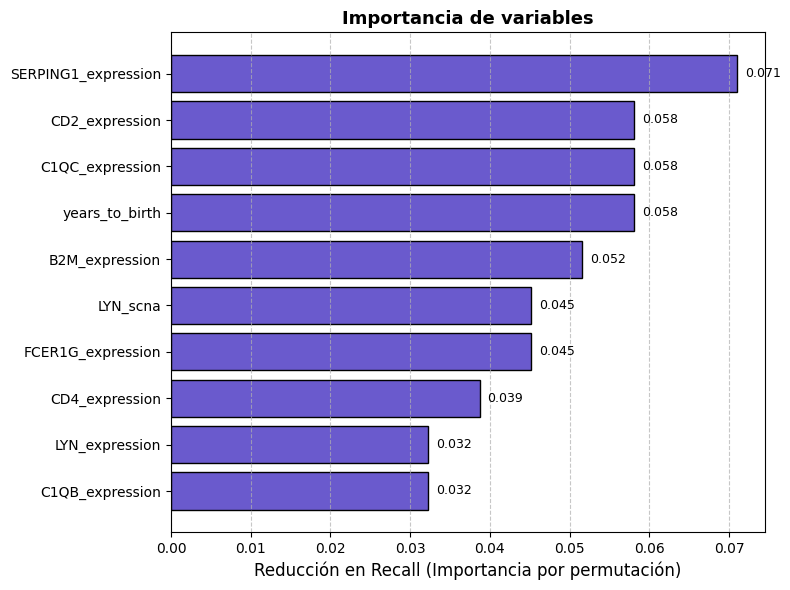

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Top 10 variables del mejor modelo (Random Forest)
top_features = [
    ("SERPING1_expression", 0.0710),
    ("CD2_expression", 0.0581),
    ("C1QC_expression", 0.0581),
    ("years_to_birth", 0.0581),
    ("B2M_expression", 0.0516),
    ("LYN_scna", 0.0452),
    ("FCER1G_expression", 0.0452),
    ("CD4_expression", 0.0387),
    ("LYN_expression", 0.0323),
    ("C1QB_expression", 0.0323)
]

# Convertir a DataFrame y ordenar (más importante arriba)
df = pd.DataFrame(top_features, columns=["feature", "perm_importance"])
df = df.iloc[::-1]  # invertir para que el más importante esté en la parte superior

# Crear el gráfico
plt.figure(figsize=(8, 6))
bars = plt.barh(df["feature"], df["perm_importance"], color="#6A5ACD", edgecolor='black')

# Etiquetas y formato
plt.xlabel("Reducción en Recall (Importancia por permutación)", fontsize=12)
plt.title("Importancia de variables", fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir valores numéricos en las barras
for i, v in enumerate(df["perm_importance"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center', fontsize=9)

plt.tight_layout()
#plt.savefig("../results/feature_importance_random_forest.png", dpi=300, bbox_inches='tight')
plt.show()